# Ensemble Learning 01 — Introduction to Ensemble Learning

### One question to start
On *Kaun Banega Crorepati*, when a contestant uses the **audience poll**, the most-voted answer is almost always right,
even though most people in the audience are not experts. Why?

Because each person makes **different** mistakes, and when you combine many opinions, the mistakes cancel out and
the truth remains. This is the **Wisdom of the Crowd**, and it is the whole idea behind **Ensemble Learning**:

> **Combine several machine-learning models into one bigger model that is better than any of them alone.**

### In this notebook
1. Wisdom of the crowd: a simulation
2. **Why** an ensemble can beat its best member: the probability proof
3. The catch: models must be **different** (independent)
4. How ensembles make predictions: vote (classification) and average (regression)
5. The 4 types: Voting, Bagging, Boosting, Stacking

> 📖 Theory: [`theory.md`](theory.md) §1–4 · Most code here is 🎨 *visualization only*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
CMAP = ListedColormap(['#FA8072', '#1E90FF'])

## 1. Wisdom of the crowd: guessing the weight of an ox

More than 100 years ago, visitors at a country fair guessed the weight of an ox. Individual guesses were all over
the place, but the **average** of all the guesses was almost exactly correct. Let's simulate it: 800 people, each
guessing with a large random error.

In [2]:
rng = np.random.default_rng(0)
true_weight = 543                                                # kg
guesses = true_weight + rng.normal(0, 80, size=800)              # each guess is off by ±80 kg on average

print("A typical person is off by :", round(np.mean(np.abs(guesses - true_weight)), 1), "kg")
print("Average of all 800 guesses :", round(guesses.mean(), 1), "kg  (truth:", true_weight, "kg)")

A typical person is off by : 64.2 kg
Average of all 800 guesses : 540.9 kg  (truth: 543 kg)


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

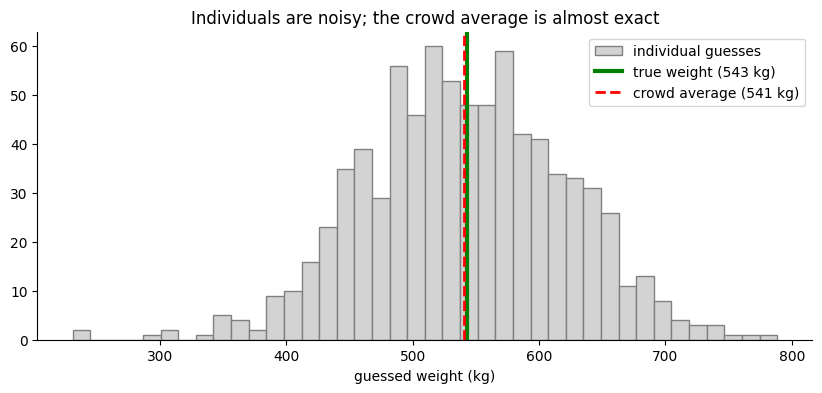

In [3]:
plt.figure(figsize=(10, 4))
plt.hist(guesses, bins=40, color='lightgray', edgecolor='gray', label='individual guesses')
plt.axvline(true_weight, color='green', linewidth=3, label=f'true weight ({true_weight} kg)')
plt.axvline(guesses.mean(), color='red', linestyle='--', linewidth=2, label=f'crowd average ({guesses.mean():.0f} kg)')
plt.xlabel('guessed weight (kg)')
plt.title('Individuals are noisy; the crowd average is almost exact')
plt.legend()
plt.show()

Individual errors are large, but because they point in **different directions**, they cancel when averaged.
The same thing happens with Amazon reviews (a 4.5★ rating from 15,000 people is trustworthy; from one person it is not),
IMDb ratings and elections.

## 2. Why can an ensemble beat its *best* model? The proof

Three **independent** classifiers, each **70% accurate**. The ensemble takes a majority vote, so it is right whenever
**at least 2 of the 3** are right (C = correct, W = wrong):

| Outcome | Probability |
|---|---|
| C C C | $0.7^3 = 0.343$ |
| exactly 2 correct (3 ways) | $3 \times 0.7^2 \times 0.3 = 3 \times 0.147 = 0.441$ |
| exactly 1 correct (3 ways) | $3 \times 0.7 \times 0.3^2 = 0.189$ |
| W W W | $0.3^3 = 0.027$ |

$$P(\text{majority correct}) = 0.343 + 0.441 = \mathbf{0.784} \;>\; 0.7$$

Three 70% models give a **78.4%** ensemble. Let's verify by simulation:

In [4]:
n_questions = 100_000
p = 0.7
# each row = one question; each column = one model; True = that model answered correctly
correct = rng.random((n_questions, 3)) < p
majority_correct = correct.sum(axis=1) >= 2

print("Each model alone :", correct.mean(axis=0).round(3))
print("Majority vote    :", majority_correct.mean().round(3))

Each model alone : [0.703 0.7   0.698]
Majority vote    : 0.784


### More models, and the 50% condition

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

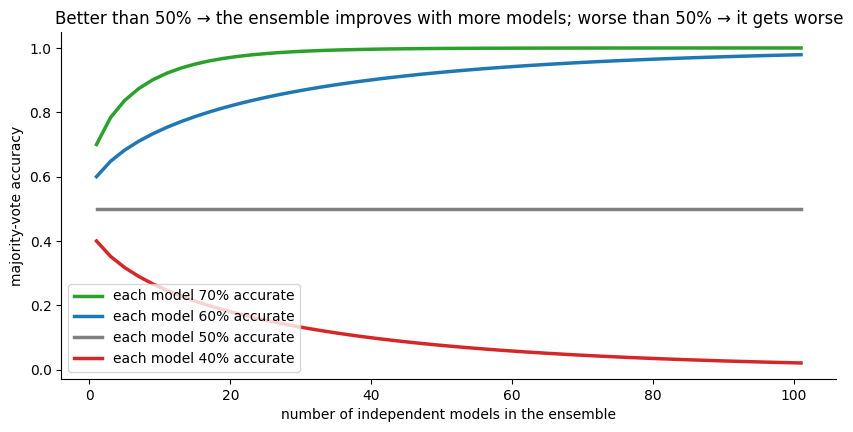

In [5]:
from scipy.stats import binom

ns = np.arange(1, 102, 2)              # odd numbers of models, so there are no ties
fig, ax = plt.subplots(figsize=(10, 4.5))
for p_model, color in [(0.7, 'tab:green'), (0.6, 'tab:blue'), (0.5, 'gray'), (0.4, 'tab:red')]:
    acc = [1 - binom.cdf(n // 2, n, p_model) for n in ns]          # P(more than half are correct)
    ax.plot(ns, acc, color=color, linewidth=2.5, label=f'each model {p_model:.0%} accurate')
ax.set_xlabel('number of independent models in the ensemble')
ax.set_ylabel('majority-vote accuracy')
ax.set_title('Better than 50% → the ensemble improves with more models; worse than 50% → it gets worse')
ax.legend()
plt.show()

Two conditions make the magic work:
1. **Each model must be better than random guessing** (> 50% for two classes). With 30%-accurate models, the same
   calculation gives $0.027 + 3 \times 0.063 = 0.216$: the ensemble is *worse* than each member.
2. **The models must make different (independent) mistakes.** That is the next experiment.

## 3. The catch: models must be different

In [6]:
def ensemble_accuracy(n_models, p, shared):
    # 'shared' = probability that a question is decided by one common error source (the same mistake for all models)
    common = rng.random((n_questions, 1)) < p
    own = rng.random((n_questions, n_models)) < p
    use_common = rng.random((n_questions, 1)) < shared
    correct = np.where(use_common, common, own)
    return (correct.sum(axis=1) > n_models / 2).mean()

for shared in [0.0, 0.5, 0.9, 1.0]:
    print(f"models share {shared:.0%} of their mistakes -> 11-model ensemble accuracy = "
          f"{ensemble_accuracy(11, 0.7, shared):.3f}")

models share 0% of their mistakes -> 11-model ensemble accuracy = 0.921
models share 50% of their mistakes -> 11-model ensemble accuracy = 0.812
models share 90% of their mistakes -> 11-model ensemble accuracy = 0.721
models share 100% of their mistakes -> 11-model ensemble accuracy = 0.699


- **Independent models (0% shared):** 11 models at 70% give an ensemble of about 92%.
- **Identical models (100% shared):** the ensemble is just 70%, no better than one model.

This is why a KBC audience full of only software engineers would be worse than a mixed audience of engineers, doctors,
lawyers and teachers. **Diversity is everything.** An ensemble gets diversity in three ways:
- **different algorithms** on the same data (→ *Voting*, *Stacking*),
- the **same algorithm on different samples** of the data (→ *Bagging*, *Random Forest*),
- or both.

## 4. How an ensemble predicts: vote or average

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

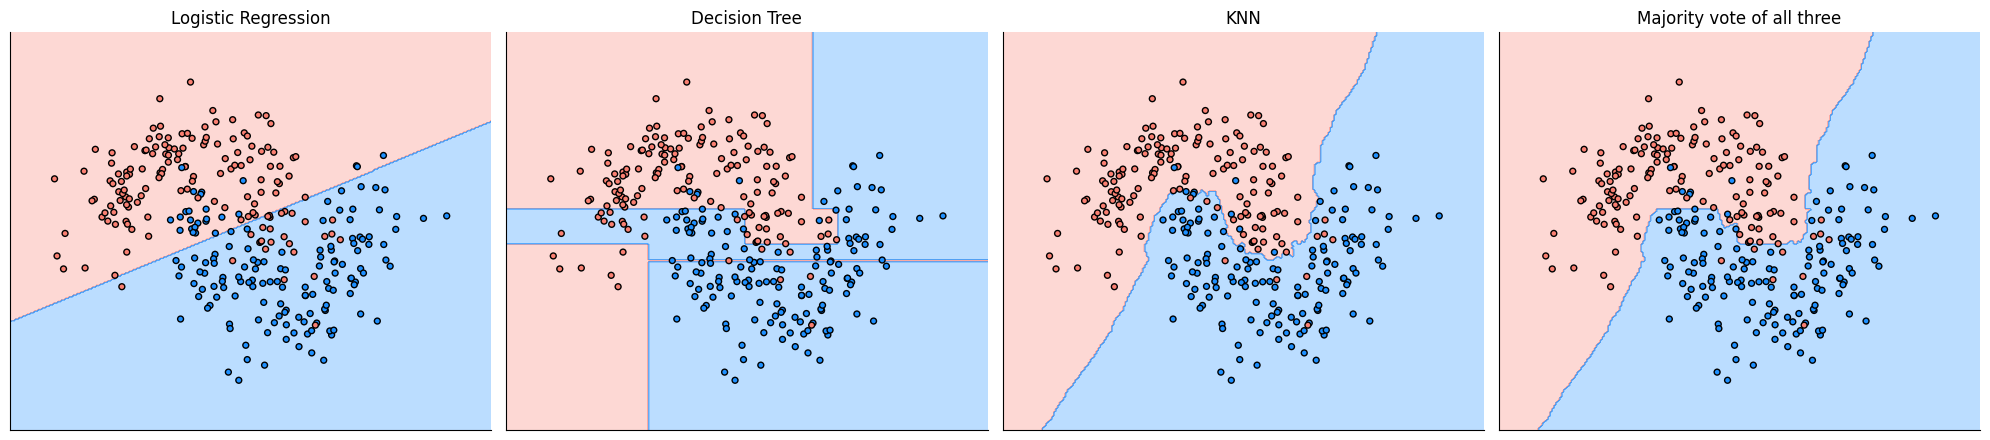

In [7]:
def plot_boundary(ax, model, X, y, title=''):
    # Colour each point of a grid by the model's prediction, then draw the data on top.
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    A, B = np.meshgrid(x0, x1)
    Z = model.predict(np.c_[A.ravel(), B.ravel()]).reshape(A.shape)
    ax.contourf(A, B, Z, alpha=0.3, cmap=CMAP)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolor='k', s=18)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

Xm, ym = make_moons(n_samples=300, noise=0.3, random_state=0)
models = [('Logistic Regression', LogisticRegression()),
          ('Decision Tree', DecisionTreeClassifier(max_depth=4, random_state=0)),
          ('KNN', KNeighborsClassifier(n_neighbors=15))]
vote = VotingClassifier(models).fit(Xm, ym)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, m) in zip(axes, models):
    plot_boundary(ax, m.fit(Xm, ym), Xm, ym, name)
plot_boundary(axes[3], vote, Xm, ym, 'Majority vote of all three')
plt.tight_layout()
plt.show()

Each model has its own weakness: logistic regression can only draw a straight line, the tree draws boxes, KNN is
wiggly. The **majority vote** keeps what most of them agree on, giving a balanced boundary.

For **regression**, the ensemble takes the **average** of the predictions:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

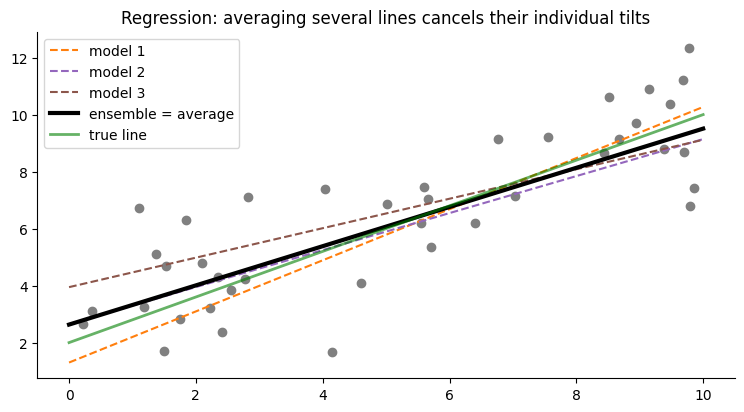

In [8]:
xr = np.sort(rng.uniform(0, 10, 40))
yr = 2 + 0.8 * xr + rng.normal(0, 1.5, 40)
grid = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(xr, yr, color='gray')
preds = []
for i, color in enumerate(['tab:orange', 'tab:purple', 'tab:brown']):
    idx = rng.choice(len(xr), size=12, replace=False)              # each model sees different data
    coef = np.polyfit(xr[idx], yr[idx], 1)
    preds.append(np.polyval(coef, grid))
    ax.plot(grid, preds[-1], color=color, linewidth=1.5, linestyle='--', label=f'model {i + 1}')
ax.plot(grid, np.mean(preds, axis=0), color='black', linewidth=3, label='ensemble = average')
ax.plot(grid, 2 + 0.8 * grid, color='green', linewidth=2, alpha=0.6, label='true line')
ax.legend()
ax.set_title('Regression: averaging several lines cancels their individual tilts')
plt.show()

## 5. The four types of ensemble learning

| Type | Base models | Data each model sees | How they are combined | Example |
|---|---|---|---|---|
| **Voting** | **different** algorithms | the same full data | majority vote / average | LR + SVM + DT |
| **Bagging** | the **same** algorithm | different **random samples** (bootstrap) | majority vote / average | Random Forest |
| **Boosting** | the same (weak) algorithm | trained **one after another**, each fixing the previous one's mistakes | weighted vote / sum | AdaBoost, Gradient Boosting, XGBoost |
| **Stacking** | different algorithms | the same data | a **meta-model** learns how to combine them | LR + SVM + DT → KNN on top |

### Benefits and the one cost
- ✅ **Better performance**: usually higher accuracy than any single model.
- ✅ **Lower bias *and* lower variance**: e.g. bagging keeps a deep tree's low bias but cuts its variance.
- ✅ **Robustness**: results change less when the data changes.
- ❌ **More computation**: you train and run many models.

**When to use:** once you have cleaned the data, engineered features and tried single models, an ensemble is usually
the final step that squeezes out the best performance, especially on tabular data and in Kaggle competitions.

---
## 🧠 Quick check

<details><summary>1. Three independent models are each 70% accurate. What is the majority-vote accuracy?</summary>

0.784: P(all 3 correct) + P(exactly 2 correct) = 0.343 + 3 × 0.147.
</details>

<details><summary>2. Name the two conditions for an ensemble to beat its members.</summary>

Each model better than random guessing (> 50% for 2 classes), and the models must make different / independent mistakes.
</details>

<details><summary>3. Bagging vs Voting: what is the key difference in how diversity is created?</summary>

Voting uses different algorithms on the same data; bagging uses the same algorithm on different random samples of the data.
</details>

➡️ **Next:** [`../02-voting/01-voting-classifier.ipynb`](../02-voting/01-voting-classifier.ipynb)